In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("/content/Wholesale customers data.csv")

In [ ]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.shape

(440, 8)

In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
X_question = df.iloc[:,:]
q_mean = X_question.mean(axis=0)
total_mean = q_mean.mean()
print("Q_mean -\n",q_mean)
print("Total mean of X -",total_mean)

Q_mean -
 Channel                 1.322727
Region                  2.543182
Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicassen           1524.870455
dtype: float64
Total mean of X - 4153.750284090909


In [ ]:
q_mean.reset_index(inplace=True)
q_mean.head()

,index,mean
0,Channel,1.322727
1,Region,2.543182
2,Fresh,12000.297727
3,Milk,5796.265909
4,Grocery,7951.277273


In [ ]:
total_mean

np.float64(4153.750284090909)

<Axes: xlabel='index', ylabel='mean'>

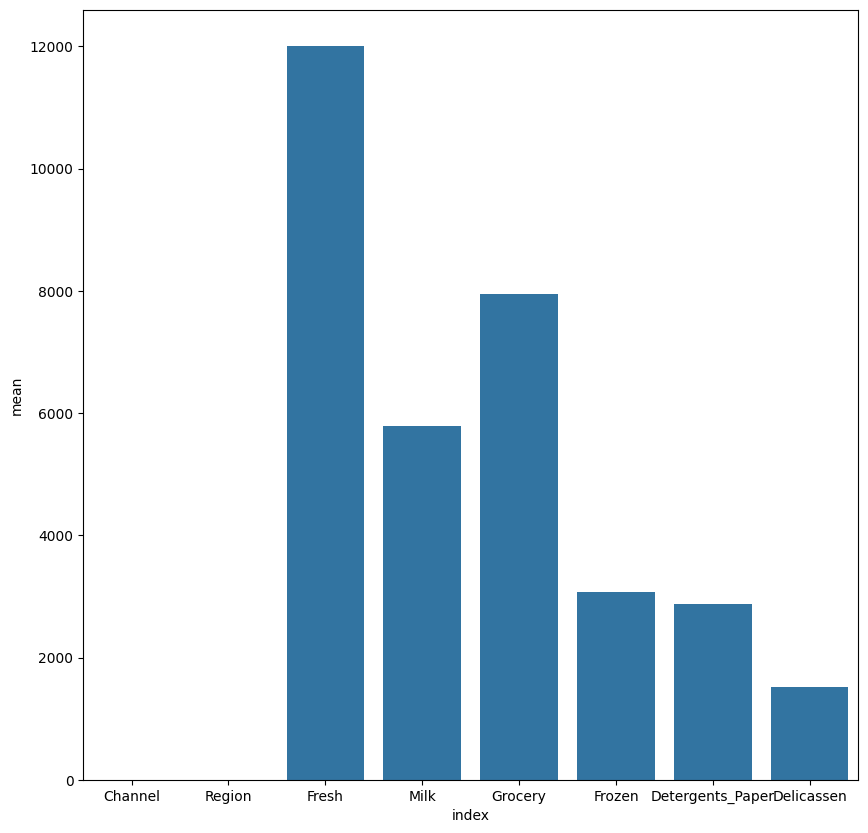

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(x='index',y='mean',data=q_mean)

<Axes: >

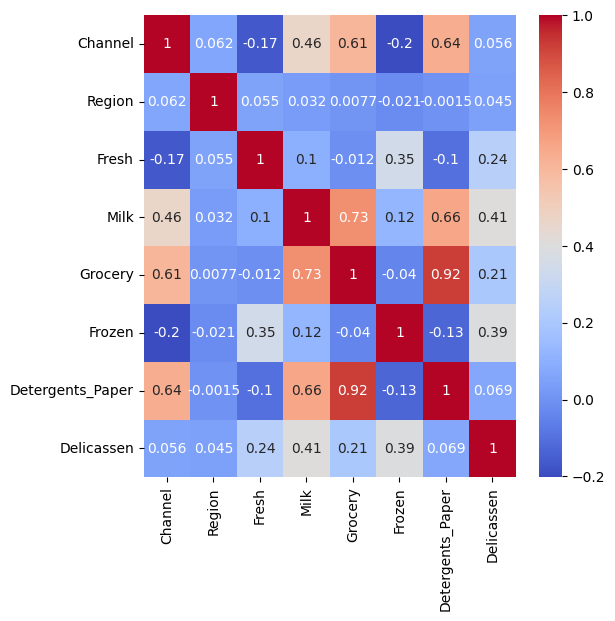

In [ ]:
corr = df.corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [ ]:
pca = PCA(n_components=2,random_state=42)
df_pca = pca.fit_transform(df)

In [ ]:
df_pca

array([[ 6.50022120e+02,  1.58551911e+03],
       [-4.42680498e+03,  4.04245152e+03],
       [-4.84199871e+03,  2.57876219e+03],
       [ 9.90346444e+02, -6.27980600e+03],
       [ 1.06579987e+04, -2.15972579e+03],
       [-2.76596159e+03, -9.59870712e+02],
       [-7.15550892e+02, -2.01300225e+03],
       [-4.47458367e+03,  1.42949698e+03],
       [-6.71209539e+03, -2.20590917e+03],
       [-4.82363437e+03,  1.34805592e+04],
       [-7.97482899e+03,  5.71121893e+03],
       [ 3.63937822e+01, -6.03789639e+03],
       [ 1.99402020e+04,  4.59128651e+03],
       [ 9.39669557e+03,  5.91315706e+03],
       [ 1.26603704e+04,  4.54194546e+03],
       [-2.99772589e+03, -6.09387931e+03],
       [-1.05895236e+04,  6.58421595e+03],
       [-6.36709517e+03, -3.68071268e+03],
       [ 6.62382533e+03,  1.25471955e+03],
       [-4.86153157e+03, -2.25592277e+02],
       [ 4.79424416e+03, -3.98879934e+03],
       [-7.24486683e+03, -7.34772327e+03],
       [ 1.92992657e+04, -6.93681067e+03],
       [ 1.

In [ ]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.8647858832196772)

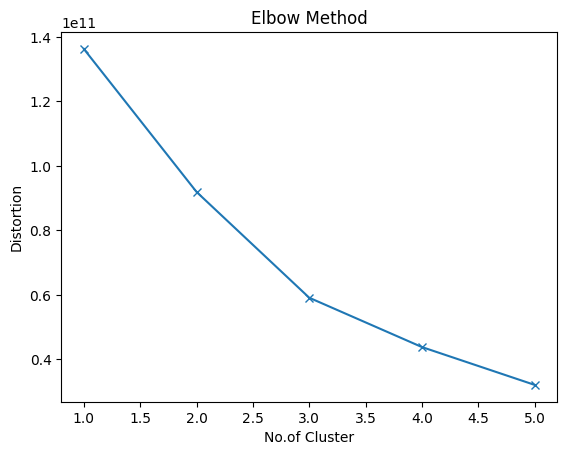

In [ ]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(df_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='x')
plt.xlabel("No.of Cluster")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [ ]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)
y = model.fit_predict(df_pca)

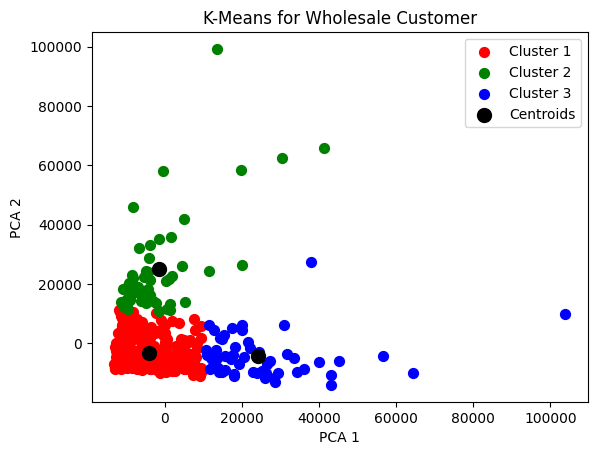

In [ ]:
plt.scatter(df_pca[y==0,0],df_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(df_pca[y==1,0],df_pca[y==1,1],s=50,c='green',label='Cluster 2')
plt.scatter(df_pca[y==2,0],df_pca[y==2,1],s=50,c='blue',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means for Wholesale Customer")
plt.legend()
plt.show()